In [19]:
kvmer_results = {
    "K12_MG1655_isolates": [0.9684175302882675, 0.9689322953718571, 0.9689115910258965, 0.9695486971865291, 0.9709146532088786, 0.9709863268896837, 0.9717182244540243, 0.9717726209048362, 0.9687578387598454, 0.9744177315156458],
    "O157_H7_isolates": [0.9685194493538501, 0.9691871123276663, 0.969390751584875, 0.9699388798802545, 0.9692919606114051, 0.970005970375565, 0.9711594825901755, 0.9707255241237777, 0.9677700167886086, 0.9742568320054827],
    "Mixture": [0.9650327997204393, 0.9654571790029519, 0.9662485519494084, 0.9669809698357401, 0.9666410906559485, 0.9674295867195138, 0.9690009671915583, 0.9687887267079004, 0.9651148656861553, 0.9712906321218664]
}

kvmer_results_filtered = {
    "K12_MG1655_isolates": [0.9696364281730135, 0.9697628933909278, 0.9699633304572908, 0.9705787513203981, 0.9716344556587886, 0.9718439390187825, 0.9727024567788899, 0.9723230433426878, 0.9688413977115296, 0.9749493558594939],
    "O157_H7_isolates": [0.9699578723439894, 0.9698649535454011, 0.9706379872153273, 0.9705019078368066, 0.970730001512173, 0.9707918333966177, 0.9719890483497308, 0.9713572298231494, 0.9682607125406301, 0.9754042609210786],
    "Mixture": [0.9692501819946615, 0.96924602181119, 0.9698148492550576, 0.9699673465474168, 0.9710309680324672, 0.9707549090580038, 0.9716507908765184, 0.9712553738780062, 0.9681081581627928, 0.9747734649500379]
}

In [17]:
kvmer_results = {
    "compare_strains": [0.991076740035693,
0.9936974789915967,
0.9933554817275747,
0.9960474308300395,
0.9948107448107448,
0.9957042037434796,
0.9959938366718027,
0.994740099009901,
0.998755832037325,
0.9968857053877297]
}

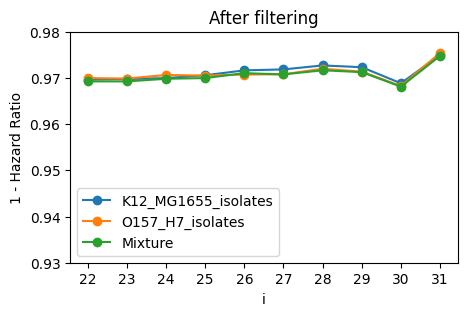

In [22]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np

k = 21
x = k + np.arange(1, 11)
data = kvmer_results_filtered
plt.figure(figsize=(5, 3))
plt.plot(x, data["K12_MG1655_isolates"], marker='o', label='K12_MG1655_isolates')
plt.plot(x, data["O157_H7_isolates"], marker='o', label='O157_H7_isolates')
plt.plot(x, data["Mixture"], marker='o', label='Mixture')

# Also plot a horizontal line at y=0.95 for reference
#plt.axhline(y=0.96, color='r', linestyle='--', label='Ground truth read identity')

plt.title(f'After filtering')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.ylim(0.93, 0.98)
plt.xticks(x)
plt.legend()

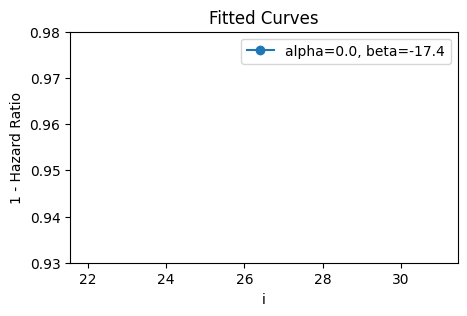

Fitted parameters for compare_strains: alpha = 0.040115, beta = -17.354606


In [18]:
from scipy.optimize import curve_fit

num_trim_values = 0
x = k + np.arange(1, 11)
# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
data = kvmer_results
fit_params = {}
for key, values in data.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in data.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [11]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for K12_MG1655_isolates: mean = 0.03575891311272336, variance = 0.00041468721742446267
Fitted parameters for O157_H7_isolates: mean = 0.03275609592990061, variance = 0.0002511243658944662
Fitted parameters for Mixture: mean = 0.03666275655140833, variance = 0.00039910022147368813


In [14]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for K12_MG1655_isolates: mean = 0.04906497546813436, variance = 0.0011385300622229273
Fitted parameters for O157_H7_isolates: mean = 0.041479108669424204, variance = 0.0005693820349338876
Fitted parameters for Mixture: mean = 0.05108671881477801, variance = 0.001002891201602386
